In [47]:
import pandas as pd

In [48]:
import matplotlib.pyplot as plt

In [49]:
import Main

In [50]:
import importlib

In [51]:
from IPython.display import display
import ipywidgets as widgets
from io import StringIO

In [52]:
importlib.reload(Main)

<module 'Main' from 'D:\\coderviewsTech.Pvt.ltd\\Main\\Main.py'>

In [53]:
upload_widget = widgets.FileUpload(accept='.csv', multiple=False)

In [55]:
display(upload_widget)

FileUpload(value=({'name': 'retaildata_set.csv', 'type': 'application/vnd.ms-excel', 'size': 6825, 'content': …

**Upload Your File Here:**

In [56]:
import pandas as pd
from io import StringIO

def read_uploaded_file(upload_widget):
    if upload_widget.value:
        file_content = upload_widget.value[0]['content']
        file_str = StringIO(bytes(file_content).decode('utf-8'))
        data = pd.read_csv(file_str)
        print("✅ File uploaded successfully!")
        return data
    else:
        print("No file uploaded!")


**Result Of Your File:**

In [57]:
data = read_uploaded_file(upload_widget)

✅ File uploaded successfully!


In [58]:
data

,CustomerID,Gender,City,Product,Quantity,UnitPrice,InvoiceDate,TotalPrice
0,CUST1000,Male,New York,Chips,2,5.63,21-02-2025,11.26
1,CUST1001,Male,Phoenix,Juice,1,2.05,24-12-2024,2.05
2,CUST1002,Male,Phoenix,Pen,1,11.88,17-05-2024,11.88
3,CUST1003,Female,Los Angeles,Water Bottle,5,6.65,11-04-2025,33.25
4,CUST1004,Male,Houston,Cookies,3,4.38,24-10-2024,13.14
...,...,...,...,...,...,...,...,...
115,CUST1115,Male,Phoenix,Lotion,1,5.97,18-09-2024,5.97
116,CUST1116,Female,Phoenix,Lotion,4,13.45,06-08-2024,53.80
117,CUST1117,Female,New York,Toothpaste,3,5.60,25-04-2024,16.80
118,CUST1118,Male,Chicago,Pen,3,10.26,17-07-2024,30.78


In [59]:
column_features =Main.extract_column_features(data,dataset_name="My_Retail_Data")


**Display Columns In A File**

In [60]:
display(column_features)

,dataset,column_name,dtype,sample_value,has_keyword_quantity,has_keyword_sales,has_keyword_product,has_keyword_date,has_keyword_gender,is_numeric,mean_value,unique_values,label
0,My_Retail_Data,CustomerID,object,CUST1000,0,0,0,0,0,False,NaN,120,not_quantity
1,My_Retail_Data,Gender,object,Male,0,0,0,0,1,False,NaN,2,not_quantity
2,My_Retail_Data,City,object,New York,0,0,0,0,0,False,NaN,5,not_quantity
3,My_Retail_Data,Product,object,Chips,0,0,1,0,0,False,NaN,10,not_quantity
4,My_Retail_Data,Quantity,int64,2,1,0,0,0,0,True,2.958333,5,quantity
5,My_Retail_Data,UnitPrice,float64,5.63,0,1,0,0,0,True,10.342000,118,not_quantity
6,My_Retail_Data,InvoiceDate,object,21-02-2025,0,0,0,1,0,False,NaN,106,not_quantity
7,My_Retail_Data,TotalPrice,float64,11.26,0,1,0,0,0,True,30.004167,116,not_quantity


In [61]:
column_names = Main.get_columns_names(data)


In [62]:
column_names 

"This file contains the following column names: Index(['CustomerID', 'Gender', 'City', 'Product', 'Quantity', 'UnitPrice',\n       'InvoiceDate', 'TotalPrice'],\n      dtype='object')"

### **AVG_B_S_(Average Basket Value Size)**

In [63]:
quantity_column = column_features[column_features['has_keyword_quantity'] == 1]['column_name'].values[0]
sales_column = column_features[column_features['has_keyword_sales'] == 1]['column_name'].values[0]

In [64]:
Avg_Basket_Size = Main.calculate_average_basket_size(data, quantity_col=quantity_column )

**Result:**

In [65]:
Avg_Basket_Size

('Avg_Basket_Size', 2.96)

In [66]:
Avg_Basket_value=Main.calculate_average_basket_value(data, sales_col=sales_column)

### **AVG_B_V_(Average Basket Value)**

In [67]:
Avg_Basket_value

('Avg_Basket_Value', 10.34)

### **Most Frequently Purchased Products by Gender**

In [68]:
gender_column = column_features[column_features['has_keyword_gender'] == 1]['column_name'].values[0]
product_column = column_features[column_features['has_keyword_product'] == 1]['column_name'].values[0]

Male: Chips (purchased 31 times)
Female: Chips (purchased 35 times)


D:\coderviewsTech.Pvt.ltd\Main\Main.py:130: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=product_counts.values, y=product_counts.index, palette='viridis')


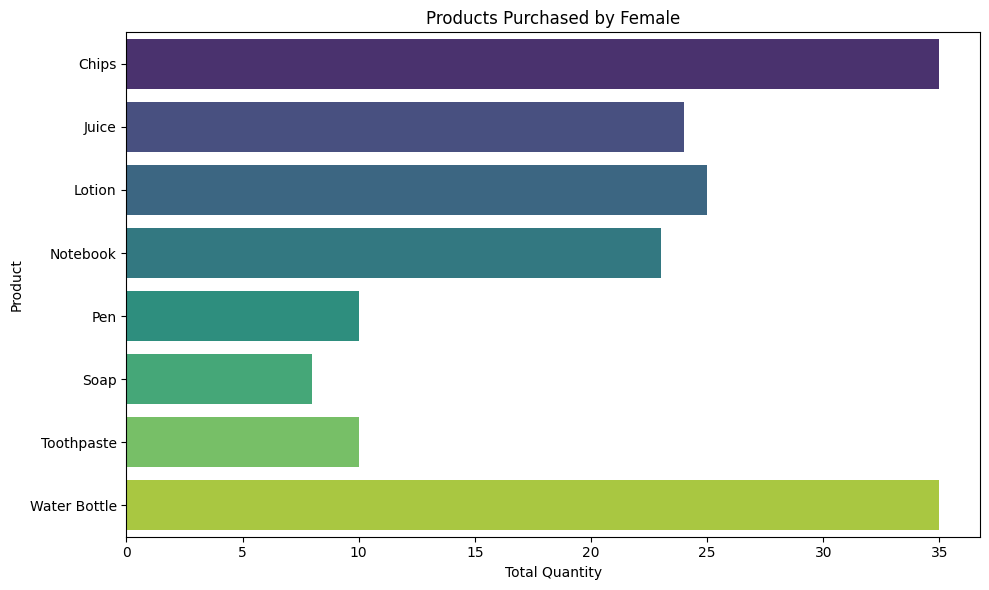

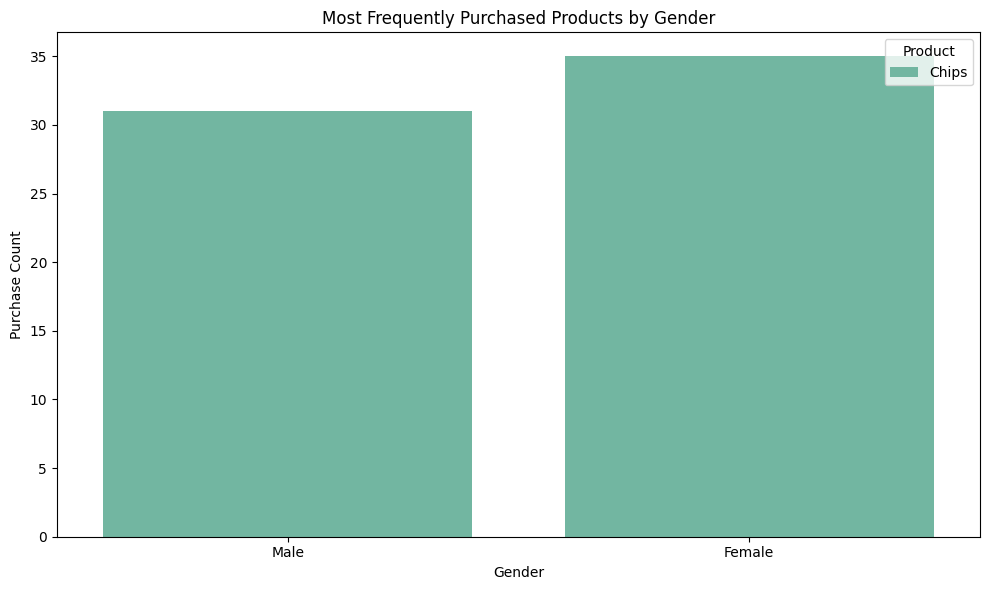


Most Frequently Purchased Products by Gender:
Male: Chips (purchased 31 times)
Female: Chips (purchased 35 times)


In [69]:
product_by_gender=Main.most_frequent_product_by_gender(data, gender_col=gender_column, product_col=product_column, quantity_col=quantity_column)

**Resilt**

Most Frequently Purchased Products by Gender:

Male: Chips (purchased 31 times)

Female: Chips (purchased 35 times)

**Find_Date_Column(For proper solution)**

In [70]:
date_column_candidates = column_features[column_features['has_keyword_date'] == 1]['column_name'].values
valid_date_column =Main. get_valid_date_column(data, candidate_cols=date_column_candidates)


D:\coderviewsTech.Pvt.ltd\Main\Main.py:163: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  converted = pd.to_datetime(df[col], errors='coerce')


In [71]:
valid_date_column

'InvoiceDate'

### **Peak Sales Period**

D:\coderviewsTech.Pvt.ltd\Main\Main.py:182: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
D:\coderviewsTech.Pvt.ltd\Main\Main.py:200: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  plt.tight_layout()
D:\coderviewsTech.Pvt.ltd\Main\Main.py:200: UserWarning: Glyph 128285 (\N{TOP WITH UPWARDS ARROW ABOVE}) missing from current font.
  plt.tight_layout()
C:\Users\Naveenkumar\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Naveenkumar\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128285 (\N{TOP WITH UPWARDS ARROW ABOVE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


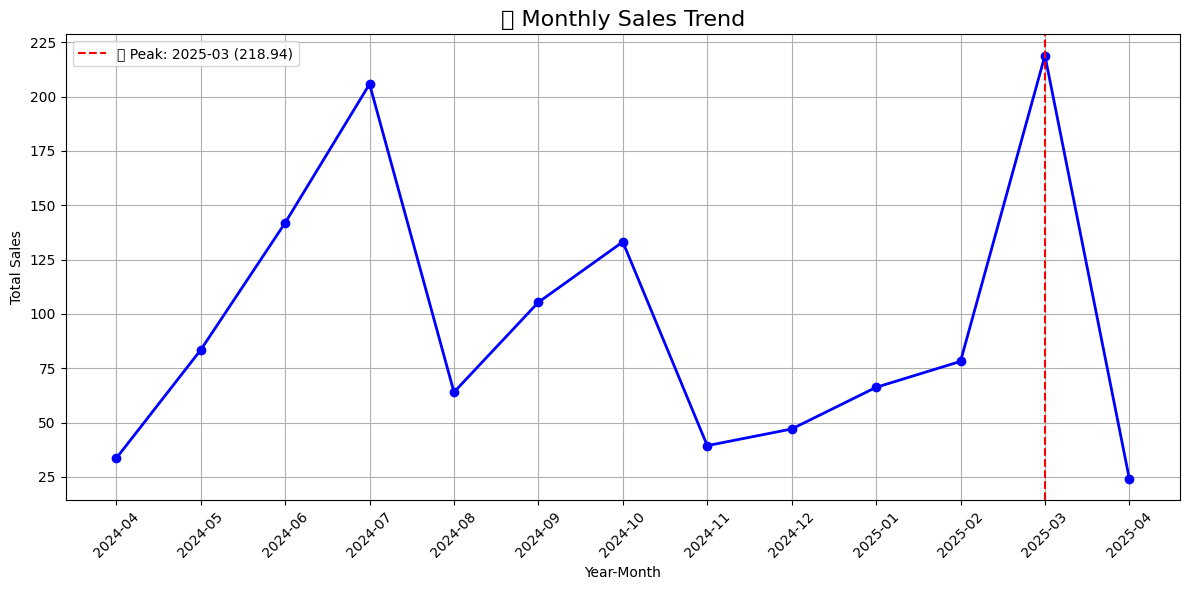


✅ Peak Sales Period: 2025-03 with sales value: 218.94


In [72]:
Main.analyze_sales_trend(data, date_col=valid_date_column, sales_col=sales_column)


**Result:**

Peak Sales Period: 2025-03 with sales value: 218.94

### **Monthly_sales_by_category**

In [73]:
category_column = column_features[column_features['has_keyword_product'] == 1]['column_name'].values[0]

D:\coderviewsTech.Pvt.ltd\Main\Main.py:232: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  plt.tight_layout()


<Figure size 1400x600 with 0 Axes>

C:\Users\Naveenkumar\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


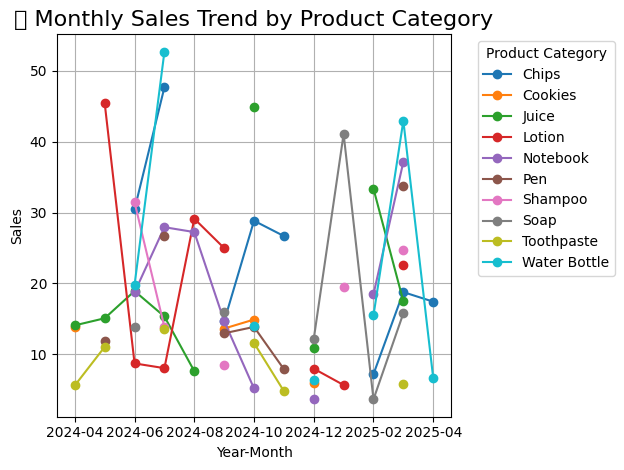


🔝 Highest Sales Month for Each Category:
   YearMonth       Product  UnitPrice
14   2024-07         Chips      47.67
33   2024-10       Cookies      14.90
34   2024-10         Juice      44.82
4    2024-05        Lotion      45.43
59   2025-03      Notebook      37.14
60   2025-03           Pen      33.70
11   2024-06       Shampoo      31.45
50   2025-01          Soap      41.08
20   2024-07    Toothpaste      13.56
21   2024-07  Water Bottle      52.69


(Product    Chips  Cookies  Juice  Lotion  Notebook    Pen  Shampoo   Soap  \
 YearMonth                                                                   
 2024-04      NaN    13.90  14.08     NaN       NaN    NaN      NaN    NaN   
 2024-05      NaN      NaN  15.08   45.43       NaN  11.88      NaN    NaN   
 2024-06    30.45      NaN  18.92    8.71     18.73    NaN    31.45  13.88   
 2024-07    47.67      NaN  15.33    8.04     27.93  26.72    13.84    NaN   
 2024-08      NaN      NaN   7.62   29.13     27.24    NaN      NaN    NaN   
 2024-09    14.63    13.63    NaN   24.98     14.69  12.96     8.51  15.97   
 2024-10    28.84    14.90  44.82     NaN      5.18  13.86      NaN    NaN   
 2024-11    26.68      NaN    NaN     NaN       NaN   7.90      NaN    NaN   
 2024-12      NaN     5.93  10.94    7.97      3.74    NaN      NaN  12.16   
 2025-01      NaN      NaN    NaN    5.66       NaN    NaN    19.48  41.08   
 2025-02     7.20      NaN  33.36     NaN     18.47    NaN      

In [74]:
Main.monthly_sales_by_category(data, date_col=valid_date_column, sales_col=sales_column, category_col=category_column)

## **Sales_by_year_and_month**


📆 Total Sales by Year:
   Year  UnitPrice
0  2024     853.66
1  2025     387.38

📅 Total Sales by Month (across years):
        Month  UnitPrice
4     January      66.22
3    February      78.15
7       March     218.94
0       April      57.65
8         May      83.43
6        June     141.92
5        July     205.78
1      August      63.99
11  September     105.37
10    October     133.17
9    November      39.38
2    December      47.04


D:\coderviewsTech.Pvt.ltd\Main\Main.py:276: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from current font.
  plt.tight_layout()
C:\Users\Naveenkumar\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


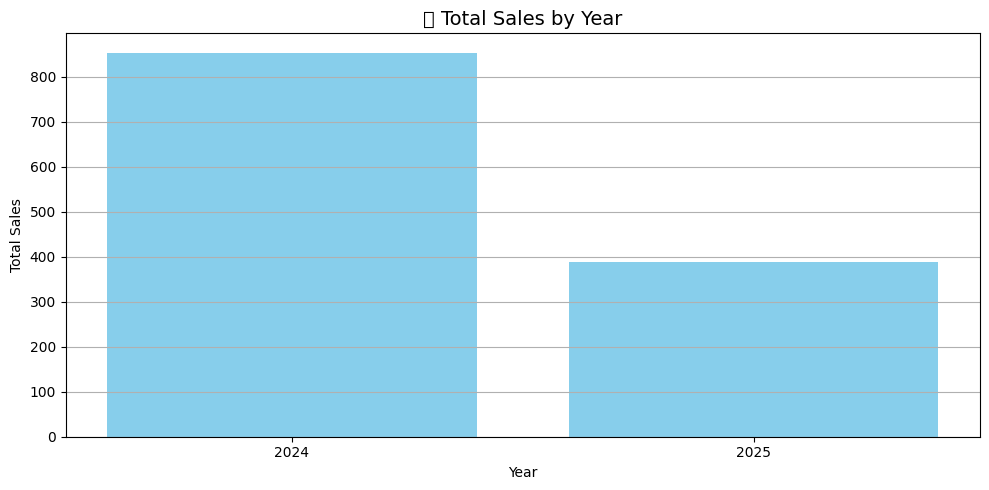

D:\coderviewsTech.Pvt.ltd\Main\Main.py:285: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from current font.
  plt.tight_layout()
C:\Users\Naveenkumar\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


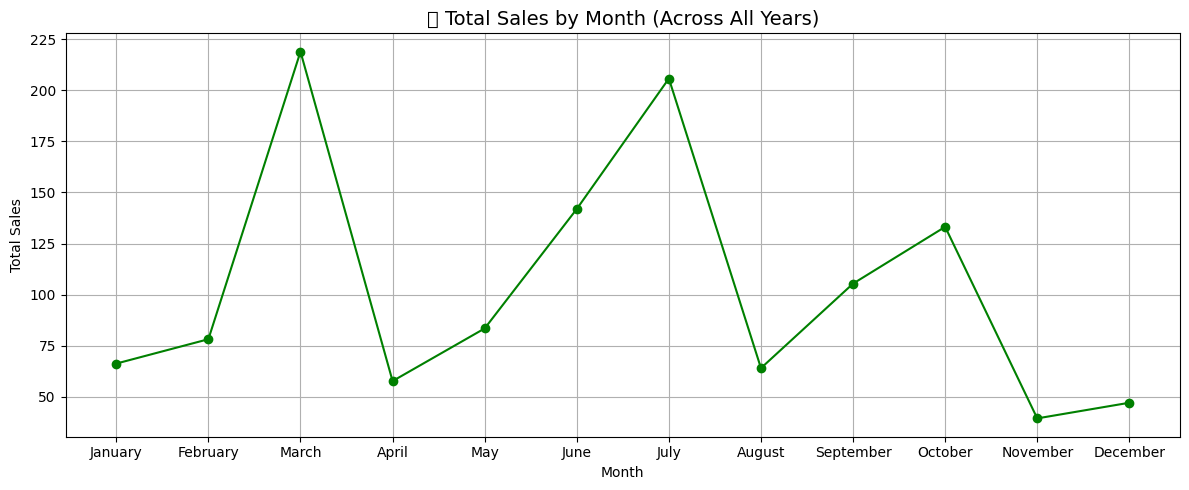

In [75]:
sales_by_year, sales_by_month = Main.sales_by_year_and_month(data, date_col=valid_date_column, sales_col=sales_column)

## **.Highest_sales_period**


📊 Highest Sales Recorded: March 2025 with total sales: 218.94


D:\coderviewsTech.Pvt.ltd\Main\Main.py:328: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from current font.
  plt.tight_layout()
C:\Users\Naveenkumar\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


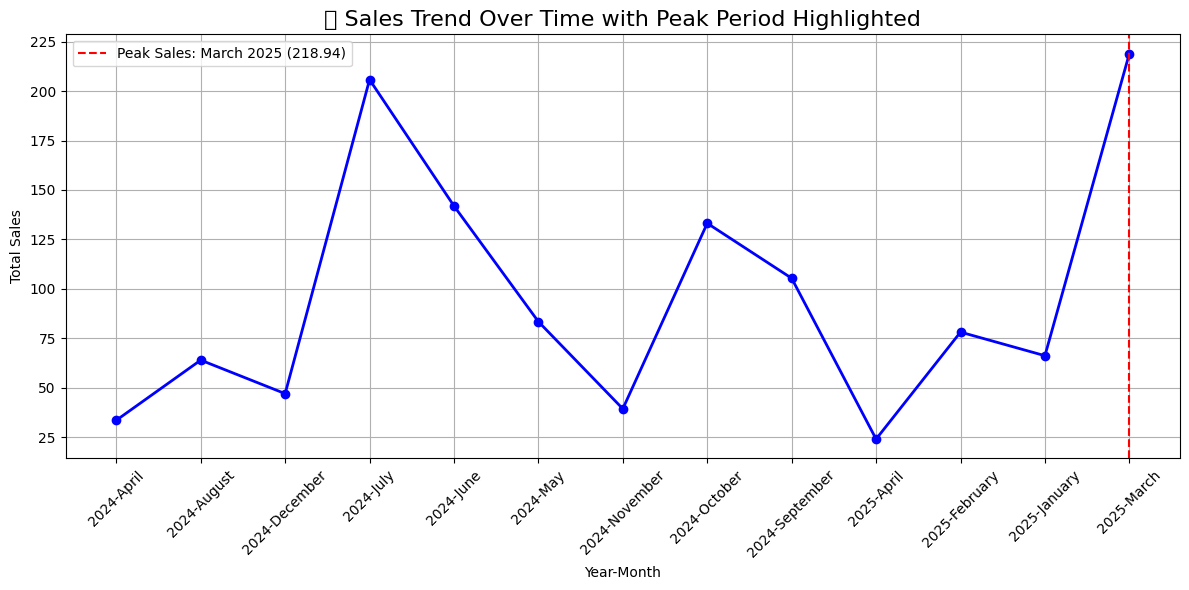

(2025, 'March', 218.94)

In [76]:
Main.highest_sales_period(data, date_col=valid_date_column, sales_col=sales_column)

**Result**

(2025, 'March', 218.94)